In [1]:
import json
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../..')
from style_setup import set_thesis_style
set_thesis_style()

# Alternative markers

## Digits

In [8]:
# Open and read the JSONL file
with open('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise_rankings/digits/small_single_source.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]


counter_1 = 0
counter_2 = 0

for i in range(len(data)):
    if data[i]['ranking_output'] == '1':
        counter_1 += 1
    elif data[i]['ranking_output'] == '2':
        counter_2 += 1

print(counter_1, counter_2)

1031 169


## Letters: A & B

In [10]:
# Open and read the JSONL file
with open('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise_rankings/a_b/small_vanilla.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]


counter_a = 0
counter_b = 0

for i in range(len(data)):
    if data[i]['ranking_output'] == 'A':
        counter_a += 1
    elif data[i]['ranking_output'] == 'B':
        counter_b += 1

print(counter_a, counter_b)
print(len(data))

622 578
1200


## Letters: B & A

In [5]:
# Open and read the JSONL file
with open('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise_rankings/b_a/small_single_source.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]


counter_a = 0
counter_b = 0

for i in range(len(data)):
    if data[i]['ranking_output'] == 'A':
        counter_a += 1
    elif data[i]['ranking_output'] == 'B':
        counter_b += 1

print(counter_a, counter_b)
print(len(data))

938 262
1200


## Letters: G & H

In [3]:
# Open and read the JSONL file
with open('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise_rankings/g_h/small_single_source.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

counter_g = 0
counter_h = 0
counter_a = 0
counter_b = 0
counter_other = 0
other_list = []

for i in range(len(data)):
    if data[i]['ranking_output'] == 'G':
        counter_g += 1
    elif data[i]['ranking_output'] == 'H':
        counter_h += 1
    elif data[i]['ranking_output'] == 'A':
        counter_a += 1
    elif data[i]['ranking_output'] == 'B':
        counter_b += 1
    else:
        counter_other += 1
        other_list.append(data[i]['ranking_output'])


print(counter_g, counter_h, counter_a, counter_b)


85 488 299 328
0


# Calculating self-preference bias

## Llama-small

### Calculating scores

In [1]:
def calculate_average_preference_7b(data_path):

    preference_llama = []
    preference_qwen = []
    preference_gemma = []
    preference_falcon = []
    preference_human = []

    with open(data_path, 'r') as f:
        data = [json.loads(line) for line in f]

    for i in range(len(data)):
        probability_a = data[i]['marker_choice_probabilities']["A"]
        probability_b = data[i]['marker_choice_probabilities']["B"]
        normalized_probability_a = probability_a / (probability_a + probability_b)
        normalized_probability_b = probability_b / (probability_a + probability_b)

        if data[i]['model_a'] == 'llama':
            preference_llama.append(normalized_probability_a)
        if data[i]['model_b'] == 'llama':
            preference_llama.append(normalized_probability_b)
        if data[i]['model_a'] == 'qwen':
            preference_qwen.append(normalized_probability_a)
        if data[i]['model_b'] == 'qwen':
            preference_qwen.append(normalized_probability_b)
        if data[i]['model_a'] == 'gemma':
            preference_gemma.append(normalized_probability_a)
        if data[i]['model_b'] == 'gemma':
            preference_gemma.append(normalized_probability_b)
        if data[i]['model_a'] == 'falcon':
            preference_falcon.append(normalized_probability_a)
        if data[i]['model_b'] == 'falcon':
            preference_falcon.append(normalized_probability_b)
        if data[i]['model_a'] == 'human':
            preference_human.append(normalized_probability_a)
        if data[i]['model_b'] == 'human':
            preference_human.append(normalized_probability_b)


    average_preference_llama = sum(preference_llama) / len(preference_llama)
    average_preference_qwen = sum(preference_qwen) / len(preference_qwen)
    average_preference_gemma = sum(preference_gemma) / len(preference_gemma)
    average_preference_falcon = sum(preference_falcon) / len(preference_falcon)
    average_preference_human = sum(preference_human) / len(preference_human)


    preference_scores = {
        'llama': {
            "average_preference": average_preference_llama,
            "all_preferences": preference_llama
        },
        'qwen': {
            "average_preference": average_preference_qwen,
            "all_preferences": preference_qwen
        },
        'gemma': {
            "average_preference": average_preference_gemma,
            "all_preferences": preference_gemma
        },
        'falcon': {
            "average_preference": average_preference_falcon,
            "all_preferences": preference_falcon
        },
        'human': {
            "average_preference": average_preference_human,
            "all_preferences": preference_human
        }
    }

    return preference_scores




In [5]:
print("Single source")

single_source_preference_scores = calculate_average_preference_7b('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/outputs/llama_8b_single_source.jsonl')
for model, scores in single_source_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

print("########################################################")

print("Multi source")

multi_source_preference_scores = calculate_average_preference_7b('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/outputs/llama_8b_multi_source.jsonl')
for model, scores in multi_source_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

print("########################################################")

print("Human source")

human_source_preference_scores = calculate_average_preference_7b('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/outputs/llama_8b_human_source.jsonl')
for model, scores in human_source_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")


print("########################################################")

print("Vanilla")

vanilla_preference_scores = calculate_average_preference_7b('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/outputs/llama_8b_vanilla.jsonl')
for model, scores in vanilla_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

# Create a dictionary to store the results
results = {
    'Single source': {model: scores['average_preference'] for model, scores in single_source_preference_scores.items()},
    'Multi source': {model: scores['average_preference'] for model, scores in multi_source_preference_scores.items()},
    'Human source': {model: scores['average_preference'] for model, scores in human_source_preference_scores.items()},
    'Vanilla': {model: scores['average_preference'] for model, scores in vanilla_preference_scores.items()}
}

# Convert to DataFrame
df = pd.DataFrame(results).T
df = df.round(4)  # Round to 4 decimal places for readability

#df.to_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/llama_8b_preference_scores.csv")
# Display the DataFrame
print("\nPreference Scores by Model and Source:")
print(df)



Single source
llama: 0.7187221311725744
qwen: 0.5412770324589431
gemma: 0.5656961209989625
falcon: 0.4690398516784405
human: 0.2052648636910795
########################################################
Multi source
llama: 0.68098484149801
qwen: 0.5337070003588166
gemma: 0.5645174132532063
falcon: 0.46833528193055224
human: 0.25245546295941507
########################################################
Human source
llama: 0.4877015245374405
qwen: 0.5084778602262815
gemma: 0.49174706531280704
falcon: 0.501953768558936
human: 0.510119781364535
########################################################
Vanilla
llama: 0.8048958236742362
qwen: 0.5676735049354239
gemma: 0.586593092680036
falcon: 0.48740841691065556
human: 0.05342916179964821

Preference Scores by Model and Source:
                llama    qwen   gemma  falcon   human
Single source  0.7187  0.5413  0.5657  0.4690  0.2053
Multi source   0.6810  0.5337  0.5645  0.4683  0.2525
Human source   0.4877  0.5085  0.4917  0.5020  0.5101
Vanil

In [6]:
paths = {
    'Single source': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/outputs/llama_8b_single_source.jsonl',
    'Multi source': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/outputs/llama_8b_multi_source.jsonl',
    'Human source': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/outputs/llama_8b_human_source.jsonl',
    'Vanilla': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/outputs/llama_8b_vanilla.jsonl'
}

# Calculate preferences for each path
preference_scores = {}
for name, path in paths.items():
    preference_scores[name] = calculate_average_preference_7b(path)


In [18]:
# Save preference scores to JSONL file
with open('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/llama_8b_preference_scores.jsonl', 'w') as f:
    for name, scores in preference_scores.items():
        json.dump({name: scores}, f)
        f.write('\n')


In [19]:
# Create DataFrame
df = pd.DataFrame(results).T
df = df.round(4)  # Round to 4 decimal places for readability

# Display the DataFrame
print("\nPreference Scores by Model and Source:")
#df.to_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise_rankings/a_b/preference_scores.csv")
df.head(10)



Preference Scores by Model and Source:


,llama,qwen,gemma,falcon,human
Single source,0.7187,0.5413,0.5657,0.4690,0.2053
Multi source,0.6810,0.5337,0.5645,0.4683,0.2525
Human source,0.4877,0.5085,0.4917,0.5020,0.5101
Vanilla,0.8049,0.5677,0.5866,0.4874,0.0534


### Calculate statistical significance of findings

In [7]:
all_llama_preference_scores = {}
all_qwen_preference_scores = {}
all_gemma_preference_scores = {}
all_falcon_preference_scores = {}
all_human_preference_scores = {}

for i in paths.keys():
    all_llama_preference_scores[i] = preference_scores[i]["llama"]["all_preferences"]
    all_qwen_preference_scores[i] = preference_scores[i]["qwen"]["all_preferences"]
    all_gemma_preference_scores[i] = preference_scores[i]["gemma"]["all_preferences"]
    all_falcon_preference_scores[i] = preference_scores[i]["falcon"]["all_preferences"]
    all_human_preference_scores[i] = preference_scores[i]["human"]["all_preferences"]



In [15]:
score_dict = {
    "llama_scores": all_llama_preference_scores,
    "qwen_scores": all_qwen_preference_scores,
    "falcon_scores": all_falcon_preference_scores,
    "gemma_scores": all_gemma_preference_scores,
    "human_scores": all_human_preference_scores,
}



for name, score_data in score_dict.items():
    print("----------------------------------------------------")
    print(f"{name}:")
    # Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
    groups = [scores for condition, scores in score_data.items()] 
    H, p_value = stats.kruskal(*groups)

    dataset_names = [condition for condition, scores in score_data.items()] 

    print(f"Kruskal-Wallis H-test results:")
    print(f"H-statistic: {H:.2f}")
    print(f"p-value: {p_value:.2e}")

    # If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
    if p_value < 0.05:
        print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
        n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
        alpha = 0.05 / n_comparisons  # Bonferroni correction
        print(f"Bonferroni corrected alpha: {alpha}")
        
        for i in range(len(dataset_names)):
            for j in range(i + 1, len(dataset_names)):
                stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
                print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
                print(f"U-statistic: {stat:.2f}")
                print(f"p-value: {p:.2e}")
                print(f"Significant difference: {'Yes' if p < alpha else 'No'}")



NameError: name 'all_llama_preference_scores' is not defined

### Plotting

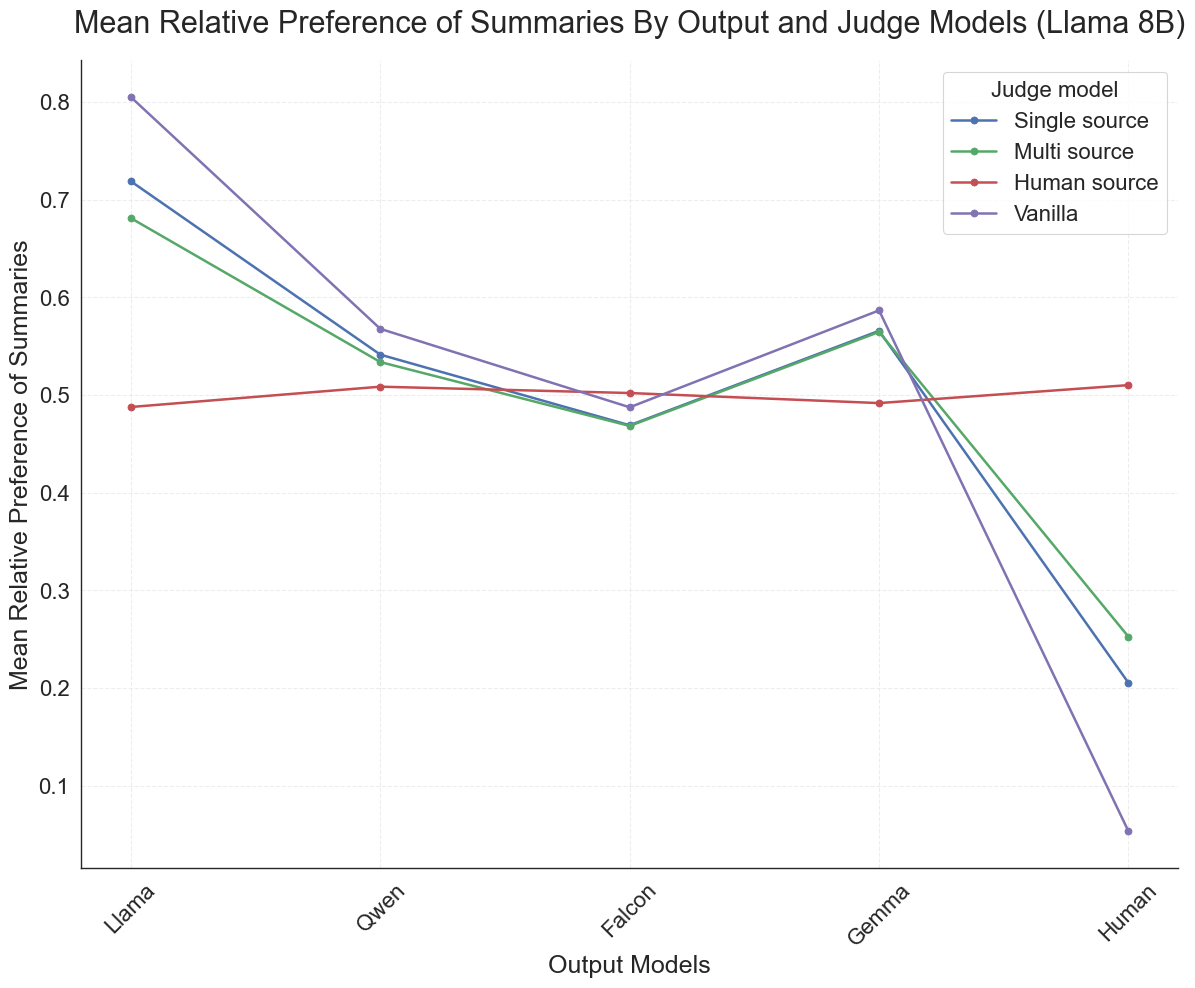

In [14]:
# Switch gemma and falcon columns
df = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/llama_8b_preference_scores.csv")
df.set_index('Unnamed: 0', inplace=True)

df = df[['llama', 'qwen', 'falcon', 'gemma', 'human']]
df.head()

plt.figure(figsize=(12, 10))
for idx, row in df.iterrows():
    plt.plot(df.columns, row.values, marker='o', label=idx)

plt.xlabel('Output Models', fontsize=18)
plt.ylabel('Mean Relative Preference of Summaries', fontsize=18)
plt.title('Mean Relative Preference of Summaries By Output and Judge Models (Llama 8B)', fontsize=22, pad=20)
plt.legend(fontsize=16, title="Judge model", title_fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=range(len(df.columns)), labels=[col.capitalize() for col in df.columns], rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/line_pairwise_small.png')
plt.show()


Summary of Preference Scores:
                llama    qwen   gemma  falcon   human
Unnamed: 0                                           
Single source  0.7187  0.5413  0.5657  0.4690  0.2053
Multi source   0.6810  0.5337  0.5645  0.4683  0.2525
Human source   0.4877  0.5085  0.4917  0.5020  0.5101
Vanilla        0.8049  0.5677  0.5866  0.4874  0.0534


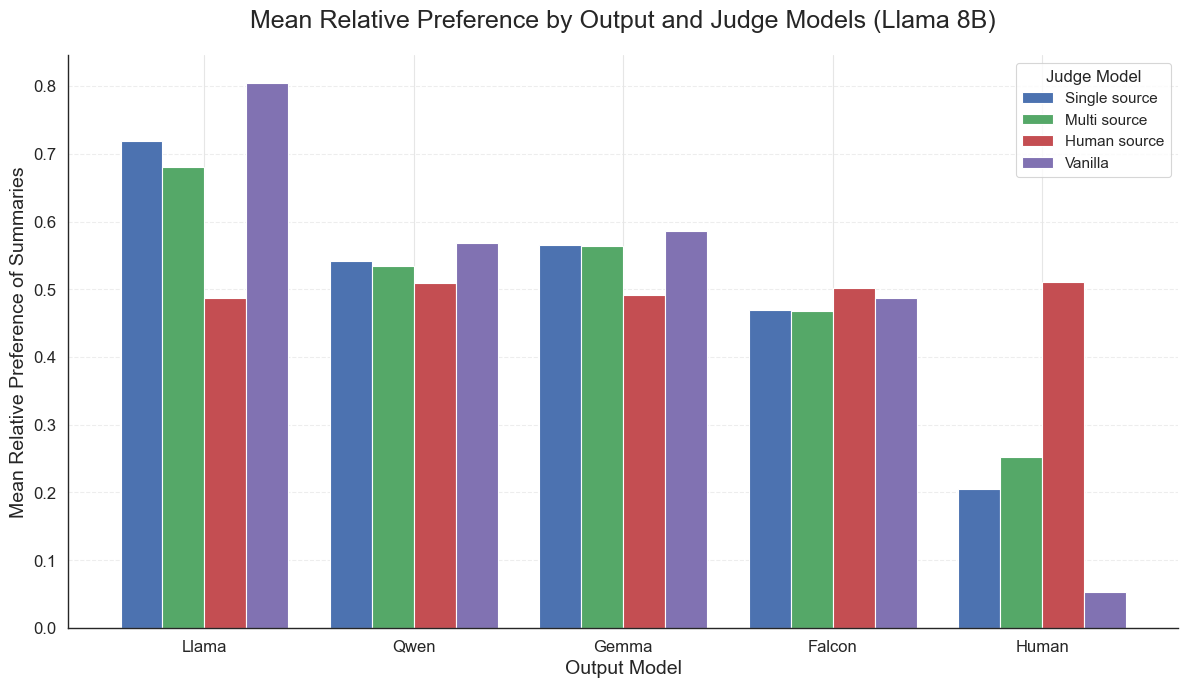

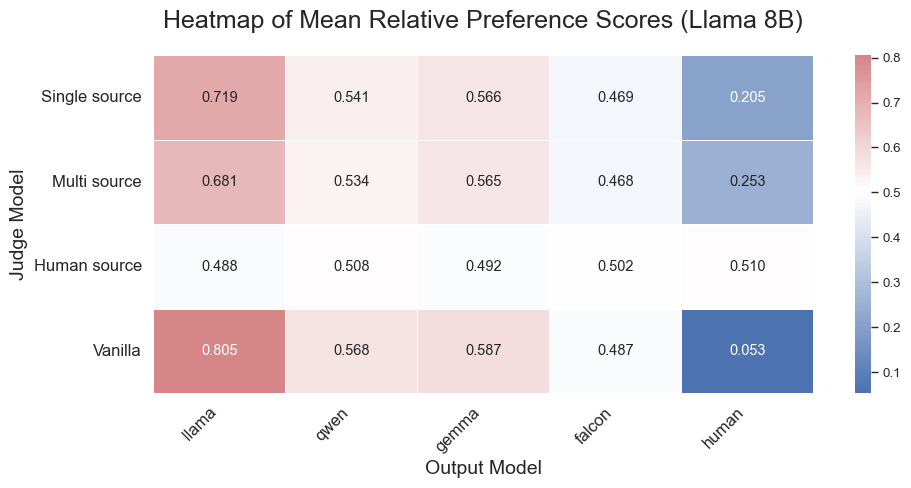

In [12]:
summary_df = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/llama_8b_preference_scores.csv")
summary_df.set_index('Unnamed: 0', inplace=True)

print("Summary of Preference Scores:")
print(summary_df)


# --- Visualization 1: Grouped Bar Chart ---
# This plot is ideal for direct comparisons.

# We need to transpose the DataFrame for easier plotting with pandas .plot()
plot_df = summary_df.T
plot_df.index = plot_df.index.str.capitalize()

plot_df.plot(kind='bar',
             stacked=False,
             figsize=(12, 7),
             width=0.8)

plt.ylabel('Mean Relative Preference of Summaries', fontsize=14)
plt.xlabel('Output Model', fontsize=14)
plt.title('Mean Relative Preference by Output and Judge Models (Llama 8B)', fontsize=18, pad=20)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Judge Model', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/bar_pairwise_small.png')
plt.show()


# --- Visualization 2: Heatmap ---

# Create a high-contrast diverging colormap using the primary blue and red
# from your project's color palette for a consistent look.
colors = ["#4C72B0", "white", "#C44E52"]  # Blue -> White -> Red
custom_cmap = sns.blend_palette(colors, as_cmap=True)


plt.figure(figsize=(10, 5))
sns.heatmap(summary_df,
            annot=True,          # Display the data values on the heatmap
            fmt=".3f",           # Format the values to 3 decimal places
            cmap=custom_cmap,    # Apply our new high-contrast colormap
            linewidths=.5,       # Add thin lines to separate cells
            center=summary_df.values.mean()) # Center the colormap on the mean value

plt.title('Heatmap of Mean Relative Preference Scores (Llama 8B)', fontsize=18, pad=20)
plt.xlabel('Output Model', fontsize=14)
plt.ylabel('Judge Model', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/heatmap_pairwise_small.png')
plt.show()

### Calculating significance of difference between ratings for different models

In [26]:
import json

with open("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/small/llama_8b_preference_scores.jsonl", "r") as f:
    llama_8b_scores = [json.loads(line) for line in f]

single_source_scores_8b = {}
multi_source_scores_8b = {}
human_source_scores_8b = {}
vanilla_scores_8b = {}

# A mapping from the condition name to the dictionary where scores should be stored.
score_map = {
    "Single source": single_source_scores_8b,
    "Multi source": multi_source_scores_8b,
    "Human source": human_source_scores_8b,
    "Vanilla": vanilla_scores_8b,
}

for condition_item in llama_8b_scores:
    # Each item is a dictionary with one key (the condition name)
    for condition_name, models_data in condition_item.items():
        if condition_name in score_map:
            target_dict = score_map[condition_name]
            # models_data contains the scores for all models under the condition
            for model_name, scores in models_data.items():
                target_dict[model_name] = scores["all_preferences"]


In [28]:
score_dict_8b = {
    "single_source_scores": single_source_scores_8b,
    "multi_source_scores": multi_source_scores_8b,
    "human_source_scores": human_source_scores_8b,
    "vanilla_scores": vanilla_scores_8b,
}



for name, score_data in score_dict_8b.items():
    print("----------------------------------------------------")
    print(f"{name}:")
    # Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
    groups = [scores for condition, scores in score_data.items()] 
    H, p_value = stats.kruskal(*groups)

    dataset_names = [condition for condition, scores in score_data.items()] 

    print(f"Kruskal-Wallis H-test results:")
    print(f"H-statistic: {H:.2f}")
    print(f"p-value: {p_value:.2e}")

    # If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
    if p_value < 0.05:
        print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
        n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
        alpha = 0.05 / n_comparisons  # Bonferroni correction
        print(f"Bonferroni corrected alpha: {alpha}")
        
        for i in range(len(dataset_names)):
            for j in range(i + 1, len(dataset_names)):
                stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
                print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
                print(f"U-statistic: {stat:.2f}")
                print(f"p-value: {p:.2e}")
                print(f"Significant difference: {'Yes' if p < alpha else 'No'}")



----------------------------------------------------
single_source_scores:
Kruskal-Wallis H-test results:
H-statistic: 950.56
p-value: 1.85e-204

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):
Bonferroni corrected alpha: 0.005

llama vs qwen:
U-statistic: 418626.50
p-value: 7.38e-27
Significant difference: Yes

llama vs gemma:
U-statistic: 404877.00
p-value: 2.31e-20
Significant difference: Yes

llama vs falcon:
U-statistic: 454063.00
p-value: 4.02e-48
Significant difference: Yes

llama vs human:
U-statistic: 587323.50
p-value: 1.82e-185
Significant difference: Yes

qwen vs gemma:
U-statistic: 306201.00
p-value: 1.34e-01
Significant difference: No

qwen vs falcon:
U-statistic: 359537.00
p-value: 1.79e-05
Significant difference: Yes

qwen vs human:
U-statistic: 502341.00
p-value: 1.59e-87
Significant difference: Yes

gemma vs falcon:
U-statistic: 373037.00
p-value: 8.70e-09
Significant difference: Yes

gemma vs human:
U-statistic: 514904.00
p-value: 1.49e-99
Sign

## Llama-medium

### Calculating the scores

In [11]:
def calculate_average_preference(data_path):

    preference_llama = []
    preference_mistral = []
    preference_qwen = []
    preference_command = []
    preference_human = []

    with open(data_path, 'r') as f:
        data = [json.loads(line) for line in f]

    for i in range(len(data)):
        probability_a = data[i]['marker_choice_probabilities']["A"]
        probability_b = data[i]['marker_choice_probabilities']["B"]
        normalized_probability_a = probability_a / (probability_a + probability_b)
        normalized_probability_b = probability_b / (probability_a + probability_b)

        if data[i]['model_a'] == 'llama':
            preference_llama.append(normalized_probability_a)
        if data[i]['model_b'] == 'llama':
            preference_llama.append(normalized_probability_b)
        if data[i]['model_a'] == 'mistral':
            preference_mistral.append(normalized_probability_a)
        if data[i]['model_b'] == 'mistral':
            preference_mistral.append(normalized_probability_b)
        if data[i]['model_a'] == 'qwen':
            preference_qwen.append(normalized_probability_a)
        if data[i]['model_b'] == 'qwen':
            preference_qwen.append(normalized_probability_b)
        if data[i]['model_a'] == 'command':
            preference_command.append(normalized_probability_a)
        if data[i]['model_b'] == 'command':
            preference_command.append(normalized_probability_b)
        if data[i]['model_a'] == 'human':
            preference_human.append(normalized_probability_a)
        if data[i]['model_b'] == 'human':
            preference_human.append(normalized_probability_b)


    average_preference_llama = sum(preference_llama) / len(preference_llama)
    average_preference_mistral = sum(preference_mistral) / len(preference_mistral)
    average_preference_qwen = sum(preference_qwen) / len(preference_qwen)
    average_preference_command = sum(preference_command) / len(preference_command)
    average_preference_human = sum(preference_human) / len(preference_human)


    preference_scores = {
        'llama': {
            "average_preference": average_preference_llama,
            "all_preferences": preference_llama
        },
        'mistral': {
            "average_preference": average_preference_mistral,
            "all_preferences": preference_mistral
        },
        'qwen': {
            "average_preference": average_preference_qwen,
            "all_preferences": preference_qwen
        },
        'command': {
            "average_preference": average_preference_command,
            "all_preferences": preference_command
        },
        'human': {
            "average_preference": average_preference_human,
            "all_preferences": preference_human
        }
    }

    return preference_scores



In [12]:
print("Single source small")

single_source_small_preference_scores = calculate_average_preference('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_single_source_small.jsonl')
for model, scores in single_source_small_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

print("########################################################")

print("Single source medium")

single_source_medium_preference_scores = calculate_average_preference('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_single_source_medium.jsonl')
for model, scores in single_source_medium_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

print("########################################################")

print("Single source large")

single_source_large_preference_scores = calculate_average_preference('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_single_source_large.jsonl')
for model, scores in single_source_large_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

print("########################################################")

print("Multi source small")

multi_source_small_preference_scores = calculate_average_preference('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_multi_source_small.jsonl')
for model, scores in multi_source_small_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

print("########################################################")

print("Multi source medium")

multi_source_medium_preference_scores = calculate_average_preference('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_multi_source_medium.jsonl')
for model, scores in multi_source_medium_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

print("########################################################")

print("Multi source large")

multi_source_large_preference_scores = calculate_average_preference('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_multi_source_large.jsonl')
for model, scores in multi_source_large_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")

print("########################################################")

print("Human source")

human_source_preference_scores = calculate_average_preference('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_human_source.jsonl')
for model, scores in human_source_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")


print("########################################################")

print("Vanilla")

vanilla_preference_scores = calculate_average_preference('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_vanilla.jsonl')
for model, scores in vanilla_preference_scores.items():
    print(f"{model}: {scores['average_preference']}")


# Create a dictionary to store the results
results = {
    'Single source small': {model: scores['average_preference'] for model, scores in single_source_small_preference_scores.items()},
    'Single source medium': {model: scores['average_preference'] for model, scores in single_source_medium_preference_scores.items()},
    'Single source large': {model: scores['average_preference'] for model, scores in single_source_large_preference_scores.items()},
    'Multi source small': {model: scores['average_preference'] for model, scores in multi_source_small_preference_scores.items()},
    'Multi source medium': {model: scores['average_preference'] for model, scores in multi_source_medium_preference_scores.items()},
    'Multi source large': {model: scores['average_preference'] for model, scores in multi_source_large_preference_scores.items()},
    'Human source': {model: scores['average_preference'] for model, scores in human_source_preference_scores.items()},
    'Vanilla': {model: scores['average_preference'] for model, scores in vanilla_preference_scores.items()}
}

# Convert to DataFrame
df = pd.DataFrame(results).T
df = df.round(4)  # Round to 4 decimal places for readability

#df.to_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/llama_70b_preference_scores.csv")
# Display the DataFrame
print("\nPreference Scores by Model and Source:")
print(df)

Single source small
llama: 0.7111266258951241
mistral: 0.6537600138038685
qwen: 0.7054144674950642
command: 0.4077028084592758
human: 0.021996084346667315
########################################################
Single source medium
llama: 0.7572021652481289
mistral: 0.6281307749501249
qwen: 0.7229695022800923
command: 0.3821843636520898
human: 0.00951319386956423
########################################################
Single source large
llama: 0.7342282660112549
mistral: 0.6532671367049605
qwen: 0.7146557013867256
command: 0.38828298719195403
human: 0.009565908705105021
########################################################
Multi source small
llama: 0.6838020049801617
mistral: 0.6087130918945494
qwen: 0.6828014293856306
command: 0.41539493967890573
human: 0.10928853406075253
########################################################
Multi source medium
llama: 0.7162392364179279
mistral: 0.6610716607385441
qwen: 0.7139282261811627
command: 0.39535227353781843
human: 0.013408603124546

In [15]:
paths = {
    'Single source small': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_single_source_small.jsonl',
    'Single source medium': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_single_source_medium.jsonl',
    'Single source large': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_single_source_large.jsonl',
    'Multi source small': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_multi_source_small.jsonl',
    'Multi source medium': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_multi_source_medium.jsonl',
    'Multi source large': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_multi_source_large.jsonl',
    'Human source': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_human_source.jsonl',
    'Vanilla': '/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/outputs/llama_70b_vanilla.jsonl'
}

# Calculate preferences for each path
preference_scores_70b = {}
for name, path in paths.items():
    preference_scores_70b[name] = calculate_average_preference(path)


In [16]:
# Save preference scores to JSONL file
with open('/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/llama_70b_preference_scores.jsonl', 'w') as f:
    for name, scores in preference_scores_70b.items():
        json.dump({name: scores}, f)
        f.write('\n')


In [13]:
# Calculate the average preference scores for the single-source condition across sizes
single_source_overall = df.loc[['Single source small', 'Single source medium', 'Single source large']].mean()
single_source_overall.name = 'Single source'

# Calculate the average preference scores for the multi-source condition across sizes
multi_source_overall = df.loc[['Multi source small', 'Multi source medium', 'Multi source large']].mean()
multi_source_overall.name = 'Multi source'

# Get the scores for the baseline conditions from the original DataFrame
human_source = df.loc['Human source']
vanilla = df.loc['Vanilla']

# Combine the aggregated results and baselines into a new summary DataFrame
summary_df = pd.DataFrame([single_source_overall, multi_source_overall, human_source, vanilla])
summary_df = summary_df.round(4) # Round for readability

# Display the summary DataFrame
print("\nSummary of Preference Scores by Source Condition:")
print(summary_df)

# Optionally, you can save this summary to a new CSV file
#summary_df.to_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/llama_70b_preference_scores_averaged.csv")



Summary of Preference Scores by Source Condition:
                llama  mistral    qwen  command   human
Single source  0.7342   0.6451  0.7144   0.3927  0.0137
Multi source   0.7046   0.6444  0.7061   0.4007  0.0442
Human source   0.6444   0.6455  0.6778   0.4308  0.1014
Vanilla        0.8027   0.5821  0.7239   0.3873  0.0040


### Statistical significance of findings

In [17]:
all_llama_preference_scores = {}
all_qwen_preference_scores = {}
all_mistral_preference_scores = {}
all_command_preference_scores = {}
all_human_preference_scores = {}

for i in paths.keys():
    all_llama_preference_scores[i] = preference_scores_70b[i]["llama"]["all_preferences"]
    all_qwen_preference_scores[i] = preference_scores_70b[i]["qwen"]["all_preferences"]
    all_mistral_preference_scores[i] = preference_scores_70b[i]["mistral"]["all_preferences"]
    all_command_preference_scores[i] = preference_scores_70b[i]["command"]["all_preferences"]
    all_human_preference_scores[i] = preference_scores_70b[i]["human"]["all_preferences"]



In [27]:
# CHOOSE THE SIZE TO ANALYZE: 'small', 'medium', or 'large'
selected_size = 'large' 

score_dict = {
    "llama_scores": all_llama_preference_scores,
    "qwen_scores": all_qwen_preference_scores,
    "mistral_scores": all_mistral_preference_scores,
    "command_scores": all_command_preference_scores,
    "human_scores": all_human_preference_scores,
}

# Define the conditions to compare based on the selected size
keys_to_compare = [
    f'Single source {selected_size}',
    f'Multi source {selected_size}',
    'Human source',
    'Vanilla'
]

for name, score_data in score_dict.items():
    print("----------------------------------------------------")
    print(f"Analysis for: {name} (Size: {selected_size})")

    # Filter the score_data to include only the conditions we want to compare for the selected size
    filtered_score_data = {
        key: score_data[key] for key in keys_to_compare if key in score_data
    }

    # Ensure there are at least two groups to compare
    if len(filtered_score_data) < 2:
        print("Not enough data groups to perform comparison for the selected size.")
        continue

    groups = list(filtered_score_data.values())
    dataset_names = list(filtered_score_data.keys())
    
    # Perform Kruskal-Wallis H-test (non-parametric ANOVA)
    H, p_value = stats.kruskal(*groups)

    print(f"Kruskal-Wallis H-test results:")
    print(f"H-statistic: {H:.2f}")
    print(f"p-value: {p_value:.2e}")

    # If the result is significant, perform pairwise Mann-Whitney U tests
    if p_value < 0.05:
        print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
        n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
        alpha = 0.05 / n_comparisons if n_comparisons > 0 else 0.05  # Bonferroni correction
        print(f"Bonferroni-corrected alpha: {alpha:.2e}")
        
        for i in range(len(dataset_names)):
            for j in range(i + 1, len(dataset_names)):
                stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
                print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
                print(f"U-statistic: {stat:.2f}")
                print(f"p-value: {p:.2e}")
                print(f"Significant difference: {'Yes' if p < alpha else 'No'}")

----------------------------------------------------
Analysis for: llama_scores (Size: large)
Kruskal-Wallis H-test results:
H-statistic: 226.33
p-value: 8.60e-49

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):
Bonferroni-corrected alpha: 8.33e-03

Single source large vs Multi source large:
U-statistic: 333933.00
p-value: 9.06e-02
Significant difference: No

Single source large vs Human source:
U-statistic: 406670.00
p-value: 2.04e-22
Significant difference: Yes

Single source large vs Vanilla:
U-statistic: 288981.00
p-value: 6.37e-05
Significant difference: Yes

Multi source large vs Human source:
U-statistic: 393258.00
p-value: 2.94e-16
Significant difference: Yes

Multi source large vs Vanilla:
U-statistic: 274381.00
p-value: 9.22e-09
Significant difference: Yes

Human source vs Vanilla:
U-statistic: 190019.00
p-value: 8.03e-50
Significant difference: Yes
----------------------------------------------------
Analysis for: qwen_scores (Size: large)
Kruskal-Wall

### Plotting

In [28]:
display(df)

,llama,mistral,qwen,command,human
Single source small,0.7111,0.6538,0.7054,0.4077,0.0220
Single source medium,0.7572,0.6281,0.7230,0.3822,0.0095
Single source large,0.7342,0.6533,0.7147,0.3883,0.0096
Multi source small,0.6838,0.6087,0.6828,0.4154,0.1093
Multi source medium,0.7162,0.6611,0.7139,0.3954,0.0134
Multi source large,0.7139,0.6634,0.7216,0.3913,0.0098
Human source,0.6444,0.6455,0.6778,0.4308,0.1014
Vanilla,0.8027,0.5821,0.7239,0.3873,0.0040


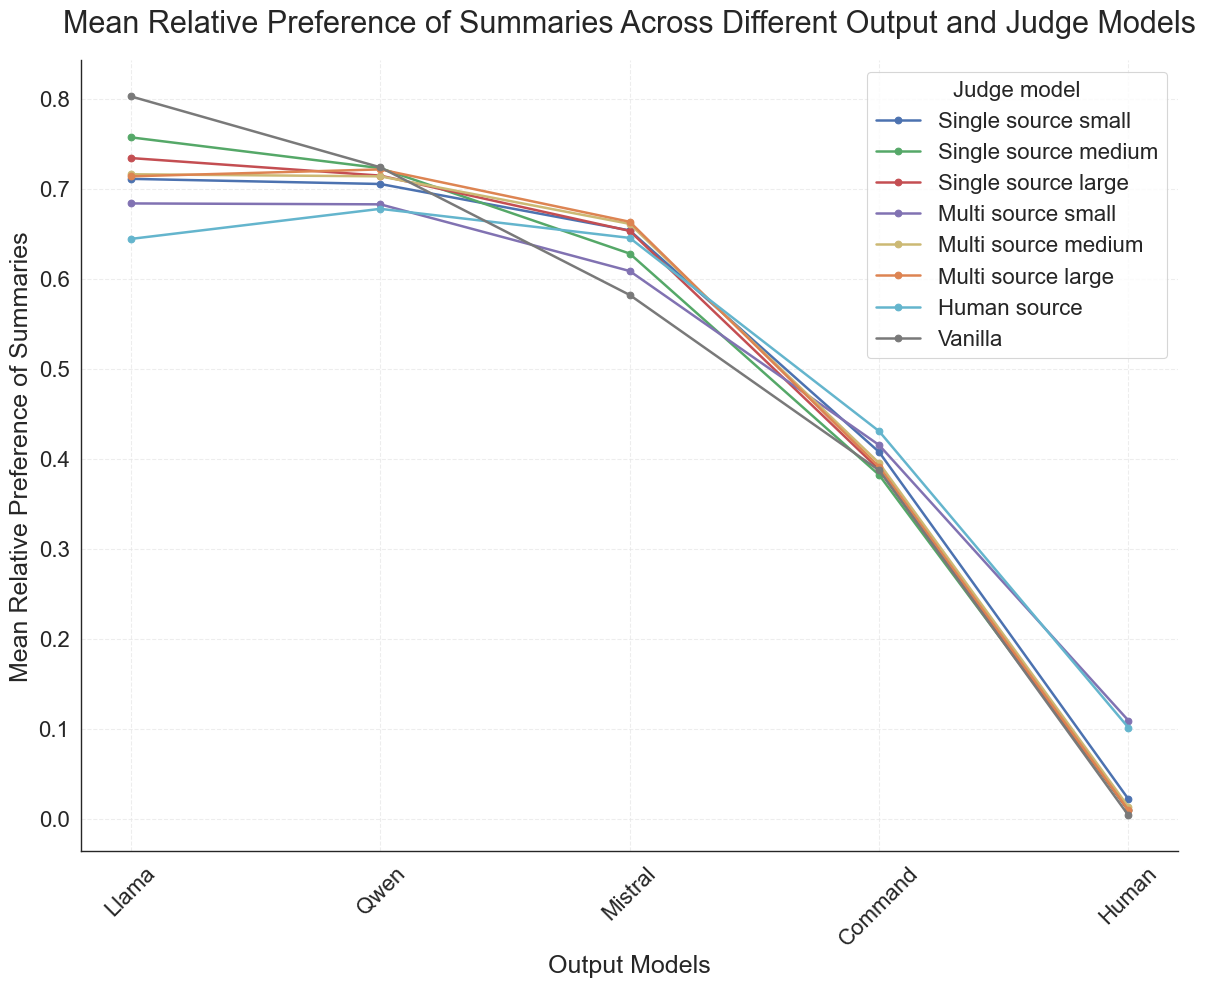

In [29]:
df = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/llama_70b_preference_scores.csv")
df.set_index('Unnamed: 0', inplace=True)

df = df[['llama', 'qwen', 'mistral', 'command', 'human']]
df.head()

plt.figure(figsize=(12, 10))
for idx, row in df.iterrows():
    plt.plot(df.columns, row.values, marker='o', label=idx)

plt.xlabel('Output Models', fontsize=18)
plt.ylabel('Mean Relative Preference of Summaries', fontsize=18)
plt.title('Mean Relative Preference of Summaries Across Different Output and Judge Models', fontsize=22, pad=20)
plt.legend(fontsize=16, title="Judge model", title_fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=range(len(df.columns)), labels=[col.capitalize() for col in df.columns], rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
#plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/line_pairwise_medium.png')
plt.show()


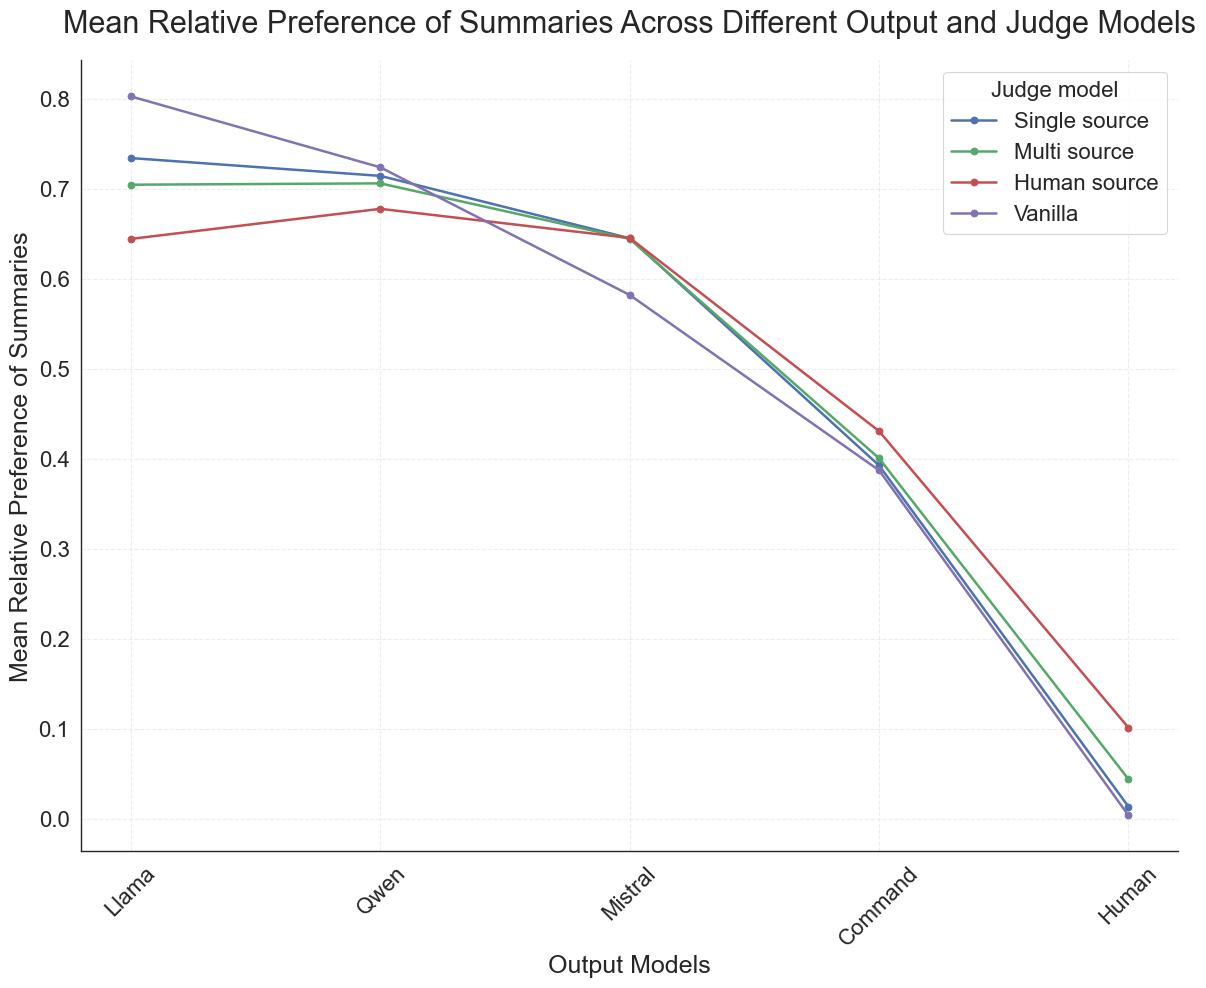

In [ ]:
df = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/llama_70b_preference_scores_averaged.csv")
df.set_index('Unnamed: 0', inplace=True)

df = df[['llama',  'qwen', 'mistral', 'command', 'human']]

plt.figure(figsize=(12, 10))
for idx, row in df.iterrows():
    plt.plot(df.columns, row.values, marker='o', label=idx)

plt.xlabel('Output Models', fontsize=18)
plt.ylabel('Mean Relative Preference of Summaries', fontsize=18)
plt.title('Mean Relative Preference of Summaries Across Different Output and Judge Models', fontsize=22, pad=20)
plt.legend(fontsize=16, title="Judge model", title_fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=range(len(df.columns)), labels=[col.capitalize() for col in df.columns], rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/line_pairwise_medium_averaged.png')
plt.show()


In [33]:
summary_df.head()

,Unnamed: 0,llama,mistral,qwen,command,human
0,Single source,0.7342,0.6451,0.7144,0.3927,0.0137
1,Multi source,0.7046,0.6444,0.7061,0.4007,0.0442
2,Human source,0.6444,0.6455,0.6778,0.4308,0.1014
3,Vanilla,0.8027,0.5821,0.7239,0.3873,0.0040


Summary of Preference Scores:
                llama    qwen  mistral  command   human
Unnamed: 0                                             
Single source  0.7342  0.7144   0.6451   0.3927  0.0137
Multi source   0.7046  0.7061   0.6444   0.4007  0.0442
Human source   0.6444  0.6778   0.6455   0.4308  0.1014
Vanilla        0.8027  0.7239   0.5821   0.3873  0.0040


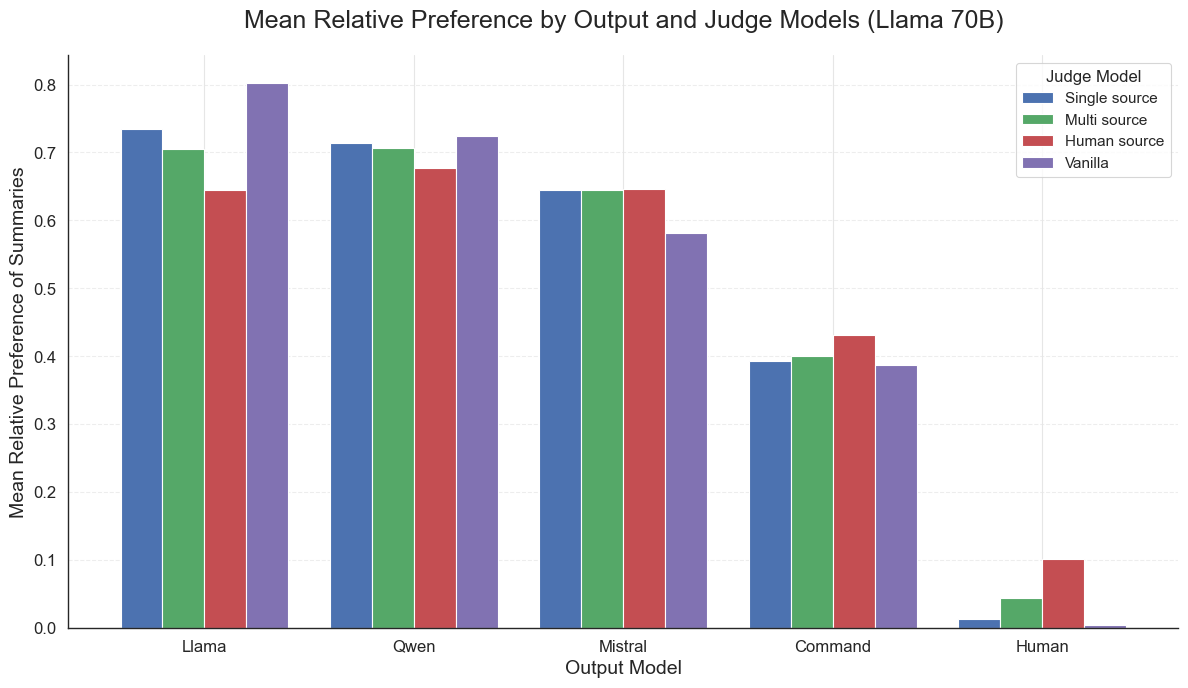

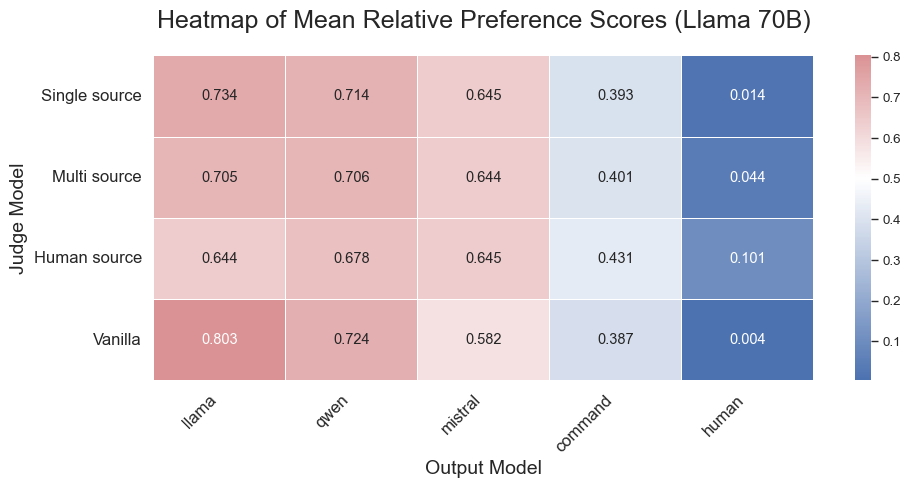

In [ ]:
summary_df = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/llama_70b_preference_scores_averaged.csv")
summary_df.set_index('Unnamed: 0', inplace=True)

column_order = ['llama', 'qwen', 'mistral', 'command', 'human']
summary_df = summary_df[column_order]


print("Summary of Preference Scores:")
print(summary_df)


# --- Visualization 1: Grouped Bar Chart ---
# This plot is ideal for direct comparisons.

# We need to transpose the DataFrame for easier plotting with pandas .plot()
plot_df = summary_df.T
plot_df.index = plot_df.index.str.capitalize()

plot_df.plot(kind='bar',
             stacked=False,
             figsize=(12, 7),
             width=0.8)

plt.ylabel('Mean Relative Preference of Summaries', fontsize=14)
plt.xlabel('Output Model', fontsize=14)
plt.title('Mean Relative Preference by Output and Judge Models (Llama 70B)', fontsize=18, pad=20)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Judge Model', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/bar_pairwise_medium_averaged.png')
plt.show()


# --- Visualization 2: Heatmap ---

colors = ["#4C72B0", "white", "#C44E52"]  # Blue -> White -> Red
custom_cmap = sns.blend_palette(colors, as_cmap=True)


plt.figure(figsize=(10, 5))
sns.heatmap(summary_df,
            annot=True,          # Display the data values on the heatmap
            fmt=".3f",           # Format the values to 3 decimal places
            cmap=custom_cmap,    # Apply our new high-contrast colormap
            linewidths=.5,       # Add thin lines to separate cells
            center=summary_df.values.mean()) # Center the colormap on the mean value

plt.title('Heatmap of Mean Relative Preference Scores (Llama 70B)', fontsize=18, pad=20)
plt.xlabel('Output Model', fontsize=14)
plt.ylabel('Judge Model', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_3/heatmap_pairwise_medium_averaged.png')
plt.show()

### Calculating significance of difference between ratings for different models

In [49]:
import json

with open("/Users/maxschaffelder/Desktop/Thesis/data/exp_3/pairwise/medium/llama_70b_preference_scores.jsonl", "r") as f:
    llama_70b_scores = [json.loads(line) for line in f]

single_source_small_scores_70b = {}
single_source_medium_scores_70b = {}
single_source_large_scores_70b = {}
multi_source_small_scores_70b = {}
multi_source_medium_scores_70b = {}
multi_source_large_scores_70b = {}
human_source_scores_70b = {}
vanilla_scores_70b = {}

# A mapping from the condition name to the dictionary where scores should be stored.
score_map = {
    "Single source small": single_source_small_scores_70b,
    "Single source medium": single_source_medium_scores_70b,
    "Single source large": single_source_large_scores_70b,
    "Multi source small": multi_source_small_scores_70b,  
    "Multi source medium": multi_source_medium_scores_70b,
    "Multi source large": multi_source_large_scores_70b,
    "Human source": human_source_scores_70b,
    "Vanilla": vanilla_scores_70b,
}

for condition_item in llama_70b_scores:
    # Each item is a dictionary with one key (the condition name)
    for condition_name, models_data in condition_item.items():
        if condition_name in score_map:
            target_dict = score_map[condition_name]
            # models_data contains the scores for all models under the condition
            for model_name, scores in models_data.items():
                target_dict[model_name] = scores["all_preferences"]


In [50]:
score_dict_70b_small = {
    "single_source_small_scores": single_source_small_scores_70b,
    "multi_source_small_scores": multi_source_small_scores_70b,
    "human_source_scores": human_source_scores_70b,
    "vanilla_scores": vanilla_scores_70b,
}

score_dict_70b_medium = {
    "single_source_medium_scores": single_source_medium_scores_70b,
    "multi_source_medium_scores": multi_source_medium_scores_70b,
    "human_source_scores": human_source_scores_70b,
    "vanilla_scores": vanilla_scores_70b,
}

score_dict_70b_large = {
    "single_source_large_scores": single_source_large_scores_70b,
    "multi_source_large_scores": multi_source_large_scores_70b,
    "human_source_scores": human_source_scores_70b,
    "vanilla_scores": vanilla_scores_70b,
}



for name, score_data in score_dict_70b_large.items():
    print("----------------------------------------------------")
    print(f"{name}:")
    # Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
    groups = [scores for condition, scores in score_data.items()] 
    H, p_value = stats.kruskal(*groups)

    dataset_names = [condition for condition, scores in score_data.items()] 

    print(f"Kruskal-Wallis H-test results:")
    print(f"H-statistic: {H:.2f}")
    print(f"p-value: {p_value:.2e}")

    # If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
    if p_value < 0.05:
        print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
        n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
        alpha = 0.05 / n_comparisons  # Bonferroni correction
        print(f"Bonferroni corrected alpha: {alpha}")
        
        for i in range(len(dataset_names)):
            for j in range(i + 1, len(dataset_names)):
                stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
                print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
                print(f"U-statistic: {stat:.2f}")
                print(f"p-value: {p:.2e}")
                print(f"Significant difference: {'Yes' if p < alpha else 'No'}")



----------------------------------------------------
single_source_large_scores:
Kruskal-Wallis H-test results:
H-statistic: 1434.00
p-value: 2.94e-309

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):
Bonferroni corrected alpha: 0.005

llama vs mistral:
U-statistic: 351921.00
p-value: 1.16e-04
Significant difference: Yes

llama vs qwen:
U-statistic: 325701.50
p-value: 4.82e-01
Significant difference: No

llama vs command:
U-statistic: 450898.50
p-value: 2.82e-52
Significant difference: Yes

llama vs human:
U-statistic: 587915.50
p-value: 5.41e-233
Significant difference: Yes

mistral vs qwen:
U-statistic: 294100.50
p-value: 1.80e-03
Significant difference: Yes

mistral vs command:
U-statistic: 419251.50
p-value: 1.37e-30
Significant difference: Yes

mistral vs human:
U-statistic: 559382.50
p-value: 5.34e-195
Significant difference: Yes

qwen vs command:
U-statistic: 444061.50
p-value: 3.35e-47
Significant difference: Yes

qwen vs human:
U-statistic: 580612.50
p-v